In [1]:
import geopandas as gpd
import pandas as pd
from pathlib import Path
import json
import re

from matplotlib.patches import Patch
from matplotlib.lines import Line2D

In [2]:
# 1. Gather every settings file under this run's settings directory. The files
#    live in a per-district-count subdirectory (settings/10/), so glob recursively.
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
settings_dir = repo_root / "outputs" / "10 X 5 STV" / "settings"
file_list = sorted(settings_dir.rglob("*.json"))

# 2. Read each settings file (a single JSON object, not line-delimited) into a
#    record, tagging the plan index and district id parsed from the filename.
_settings_re = re.compile(r"district_plan_(\d+)_district_(\d+)")

records = []
for file in file_list:
    match = _settings_re.search(file.name)
    record = json.loads(file.read_text())
    if match is not None:
        record = {
            "plan_idx": int(match.group(1)),
            "district_id": int(match.group(2)),
            **record,
        }
    records.append(record)

# 3. Build a single DataFrame with one row per settings file.
settings = pd.DataFrame(records)

print(f"Loaded {len(settings)} settings files from {settings_dir}")
settings.head()

Loaded 500 settings files from /Users/bsauvage/Documents/GitHub/mggg/Chicago-City-Council-Reform-2026/outputs/10 X 5 STV/settings


,plan_idx,district_id,num_voters,bloc_proportions,white_vap_20,asian_nhpi_vap_20,bvap_20,hvap_20,total_vap_20,slate_to_candidates,cohesion_parameters,alphas
0,0,0,10000,"{'W-A': 0.6735554461607052, 'B': 0.16781066847...",113146.0,31888.0,36134.0,34158.0,219596.0,"{'W': ['W1', 'W2', 'W3', 'W4', 'W5', 'W6', 'W7...","{'W-A': {'W': 0.9384615384615385, 'H': 0.06153...","{'W-A': {'W': 1, 'H': 1}, 'B': {'W': 1, 'H': 1..."
1,0,1,10000,"{'W-A': 0.16014525391284765, 'B': 0.5190809968...",30897.0,3237.0,110639.0,68371.0,214810.0,"{'W': ['W1', 'W2'], 'B': ['B1', 'B2', 'B3', 'B...","{'W-A': {'W': 0.782051282051282, 'B': 0.166666...","{'W-A': {'W': 1, 'B': 1, 'H': 1}, 'B': {'W': 1..."
2,0,2,10000,"{'W-A': 0.15112394268278553, 'B': 0.7222200764...",30474.0,828.0,149592.0,26234.0,208581.0,"{'B': ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7...","{'W-A': {'B': 0.7647058823529411, 'H': 0.23529...","{'W-A': {'B': 1, 'H': 1}, 'B': {'B': 1, 'H': 1..."
3,0,3,10000,"{'W-A': 0.11333375317127589, 'B': 0.8300016193...",17625.0,7570.0,184516.0,12597.0,223904.0,"{'B': ['B1', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7...","{'W-A': {'B': 1.0}, 'B': {'B': 1.0}, 'H': {'B'...","{'W-A': {'B': 1}, 'B': {'B': 1}, 'H': {'B': 1}}"
4,0,4,10000,"{'W-A': 0.15337699369549587, 'B': 0.3159441838...",29759.0,1600.0,64597.0,108501.0,205744.0,"{'B': ['B1', 'B2', 'B3', 'B4'], 'H': ['H1', 'H...","{'W-A': {'B': 0.7647058823529411, 'H': 0.23529...","{'W-A': {'B': 1, 'H': 1}, 'B': {'B': 1, 'H': 1..."


## Candidate slate representation vs. VAP share

For each candidate slate (`W`, `B`, `H`, `A`), compare two shares of the district total:

- **VAP share** — the slate's demographic group as a fraction of the district's VAP.
- **Candidate share** — candidates on that slate as a fraction of all candidates in the district.

Both shares are computed **per (plan, district) instance** (district-level ratios), then averaged **across plans** — every district instance pooled with equal weight. Where a slate's candidate share sits above its VAP share, that group's preferred candidates are over-represented on the ballot relative to its population, and vice versa.

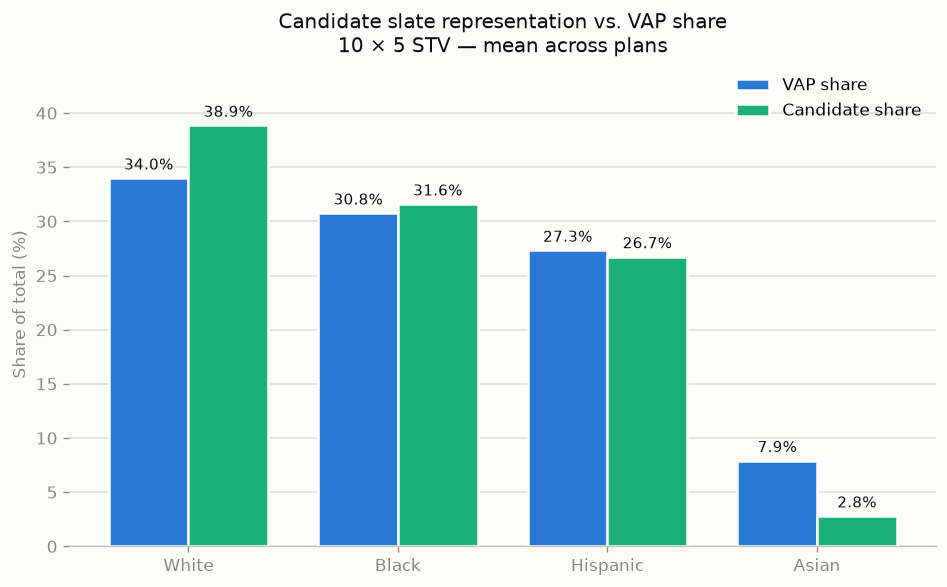

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Each candidate slate -> its VAP column, plus a readable x-axis label.
slate_vap_col = {
    "W": "white_vap_20",
    "B": "bvap_20",
    "H": "hvap_20",
    "A": "asian_nhpi_vap_20",
}
slate_label = {"W": "White", "B": "Black", "H": "Hispanic", "A": "Asian"}
slates = list(slate_vap_col)

# Per (plan, district) instance: each slate's VAP share and candidate share.
vap = settings[[slate_vap_col[s] for s in slates]].to_numpy(float)
vap_share = vap / vap.sum(axis=1, keepdims=True)

cand = np.array(
    [[len(row.get(s, [])) for s in slates] for row in settings["slate_to_candidates"]],
    dtype=float,
)
cand_share = cand / cand.sum(axis=1, keepdims=True)

# Aggregate across plans: mean share per slate (pooling all district instances).
vap_mean = vap_share.mean(axis=0) * 100
cand_mean = cand_share.mean(axis=0) * 100

# ---- Grouped bars: two measures per slate ----
SURFACE, INK, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#898781", "#e1e0d9"
VAP_COLOR, CAND_COLOR = "#2a78d6", "#1baf7a"  # categorical slots 1 (blue) & 2 (aqua)

x = np.arange(len(slates))
width = 0.38

fig, ax = plt.subplots(figsize=(8, 5), dpi=120)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

bars_vap = ax.bar(x - width / 2, vap_mean, width, label="VAP share",
                  color=VAP_COLOR, edgecolor=SURFACE, linewidth=1.5, zorder=3)
bars_cand = ax.bar(x + width / 2, cand_mean, width, label="Candidate share",
                   color=CAND_COLOR, edgecolor=SURFACE, linewidth=1.5, zorder=3)

# Direct value labels (relief rule: aqua is sub-3:1 on the light surface).
for bars in (bars_vap, bars_cand):
    for b in bars:
        ax.annotate(f"{b.get_height():.1f}%",
                    (b.get_x() + b.get_width() / 2, b.get_height()),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=9, color=INK)

ax.set_xticks(x, [slate_label[s] for s in slates])
ax.set_ylabel("Share of total (%)", color=MUTED)
ax.set_title("Candidate slate representation vs. VAP share\n"
             "10 × 5 STV — mean across plans", fontsize=12, color=INK)

# Recessive chrome: horizontal grid, no top/right/left spines.
ax.yaxis.grid(True, color=GRID, linewidth=1, zorder=0)
ax.set_axisbelow(True)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")
ax.tick_params(colors=MUTED)
ax.set_ylim(0, max(vap_mean.max(), cand_mean.max()) * 1.15)

ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
plt.show()

### Asian slate: availability vs. VAP share, by district

Zooming in on the `A` slate, aggregated **at the district level across plans**: for each
`district_id` we average the Asian VAP share and the Asian candidate share over all plans
(n = 50 each), with error bars showing the plan-to-plan standard deviation.

**Caveat on `district_id`:** each plan is an independent random districting, so `district_id`
is just a label — district 5 in one plan is unrelated to district 5 in another. The mean Asian
VAP share is therefore nearly flat across labels (~7–9%), and the large error bars reflect that
the real variation is *within* a label across plans, not *between* labels. What the chart does
show cleanly is that the gap is **consistent**: in every district the Asian candidate share
(~2–4%) sits well below the Asian VAP share, never above it.

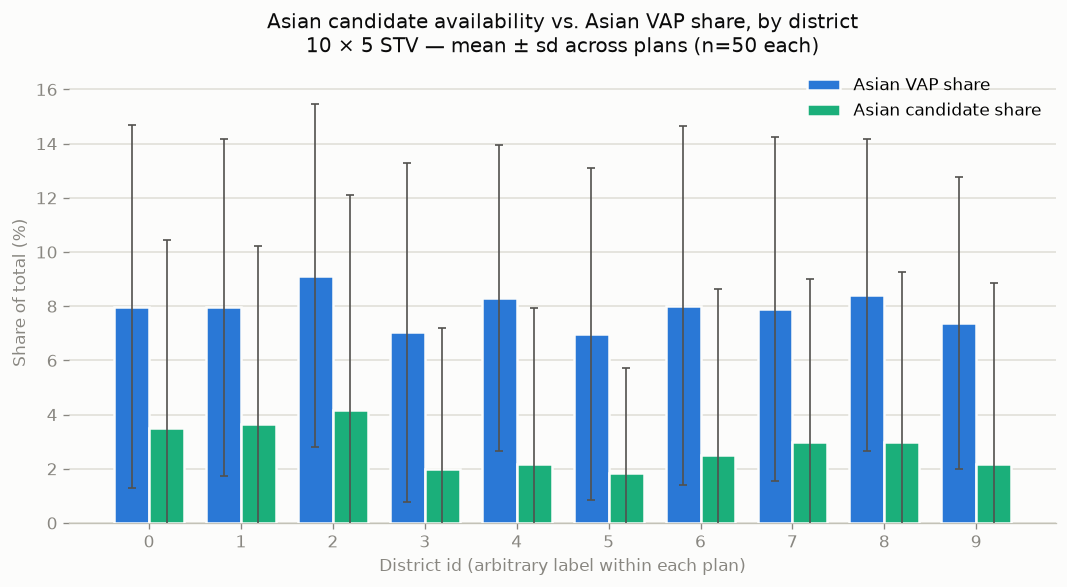

In [4]:
# Asian VAP share and Asian candidate share per (plan, district) instance.
vap_cols = ["white_vap_20", "bvap_20", "hvap_20", "asian_nhpi_vap_20"]
vap_total = settings[vap_cols].sum(axis=1)
settings["A_vap_share"] = settings["asian_nhpi_vap_20"] / vap_total
settings["A_cand_share"] = [
    len(d.get("A", [])) / sum(len(v) for v in d.values())
    for d in settings["slate_to_candidates"]
]

# Aggregate at the district level across plans: mean +/- sd per district_id.
grp = settings.groupby("district_id")
districts = sorted(settings["district_id"].unique())
vap_mean = grp["A_vap_share"].mean().reindex(districts).to_numpy() * 100
vap_sd = grp["A_vap_share"].std().reindex(districts).to_numpy() * 100
cand_mean = grp["A_cand_share"].mean().reindex(districts).to_numpy() * 100
cand_sd = grp["A_cand_share"].std().reindex(districts).to_numpy() * 100

# ---- Grouped bars per district, with plan-to-plan sd as error bars ----
SURFACE, INK, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#898781", "#e1e0d9"
VAP_COLOR, CAND_COLOR, ERR_COLOR = "#2a78d6", "#1baf7a", "#52514e"

x = np.arange(len(districts))
width = 0.38
err_kw = dict(ecolor=ERR_COLOR, elinewidth=1, capsize=2.5, capthick=1)

fig, ax = plt.subplots(figsize=(9, 5), dpi=120)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

ax.bar(x - width / 2, vap_mean, width, yerr=vap_sd, label="Asian VAP share",
       color=VAP_COLOR, edgecolor=SURFACE, linewidth=1.5, zorder=3, error_kw=err_kw)
ax.bar(x + width / 2, cand_mean, width, yerr=cand_sd, label="Asian candidate share",
       color=CAND_COLOR, edgecolor=SURFACE, linewidth=1.5, zorder=3, error_kw=err_kw)

ax.set_xticks(x, [str(d) for d in districts])
ax.set_xlabel("District id (arbitrary label within each plan)", color=MUTED)
ax.set_ylabel("Share of total (%)", color=MUTED)
ax.set_title("Asian candidate availability vs. Asian VAP share, by district\n"
             "10 × 5 STV — mean ± sd across plans (n=50 each)", fontsize=12, color=INK)

ax.yaxis.grid(True, color=GRID, linewidth=1, zorder=0)
ax.set_axisbelow(True)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")
ax.tick_params(colors=MUTED)
ax.set_ylim(0, np.nanmax(vap_mean + vap_sd) * 1.1)

ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
plt.show()

### Estimated votes for Asian candidates vs. the Droop quota

A back-of-the-envelope check of whether Asian-preferred candidates can clear quota on
**first preferences alone**, shown for **every (plan, district) instance** — all districts of
every plan along the x-axis (too many for tick labels). For each instance:

- **Expected Asian-slate votes** = `num_voters × Σ_bloc bloc_proportion[bloc] × cohesion[bloc]["A"]`
  — each bloc's share of the electorate times how cohesively that bloc ranks the `A` slate first.
- **Per Asian candidate** = that total split equally across the district's `A` candidates
  (a bar only appears where the district actually has an Asian candidate).
- **Droop quota** = `floor(num_voters / (seats + 1)) + 1`, with `seats = 5` → `floor(10000/6)+1 = 1667`.
  `num_voters` is fixed at 10,000, so the quota is the same 1,667 everywhere (one line).

Bars are colored by whether that per-candidate estimate reaches quota, and the cell prints how many
districts across all plans would elect an Asian candidate on first preferences. This is a
*first-preference* estimate — it ignores STV transfers, which can carry a candidate over quota from
below (or exhaust) — so treat it as a rough signal, not a win prediction.

In [ ]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

SEATS = 5  # configs/10x5-stv.json: district_configs winners = 5

# Expected Asian-slate first-preference votes per (plan, district) instance:
# num_voters * sum over blocs of bloc_proportion * cohesion toward the "A" slate.
def expected_A_slate_votes(row):
    bp, coh = row["bloc_proportions"], row["cohesion_parameters"]
    return row["num_voters"] * sum(bp[b] * coh[b].get("A", 0.0) for b in bp)

settings["exp_A_total"] = settings.apply(expected_A_slate_votes, axis=1)
settings["n_A"] = settings["slate_to_candidates"].apply(lambda s: len(s.get("A", [])))
# Split equally across the district's Asian candidates (undefined where there are none).
settings["exp_A_per_cand"] = np.where(
    settings["n_A"] > 0,
    settings["exp_A_total"] / settings["n_A"].replace(0, np.nan),
    np.nan,
)
settings["droop"] = np.floor(settings["num_voters"] / (SEATS + 1)) + 1

# One bar per (plan, district) instance: all districts of every plan along the x-axis.
plot_df = settings.sort_values(["plan_idx", "district_id"]).reset_index(drop=True)
droop = plot_df["droop"].iloc[0]
per_cand = plot_df["exp_A_per_cand"].to_numpy()
clears = per_cand >= droop  # NaN (no Asian candidate) -> False

n_total = len(plot_df)
n_no_A = int((plot_df["n_A"] == 0).sum())    # no bar drawn for these
n_with_A = n_total - n_no_A
n_clear = int(np.nansum(clears))
n_below = n_with_A - n_clear

print(f"Of {n_total} district instances (all districts x all plans):")
print(f"  {n_no_A:>3} have NO Asian candidate on the ballot ({n_no_A/n_total:.0%}) -- no bar drawn")
print(f"  {n_with_A:>3} have >=1 Asian candidate, of which")
print(f"      {n_clear:>3} clear the Droop quota of {droop:.0f} on first preferences "
      f"({n_clear/n_total:.1%} of all {n_total}, {n_clear/n_with_A:.0%} of the {n_with_A})")
print(f"      {n_below:>3} fall below quota")

# ---- One thin bar per instance, colored by whether it clears quota ----
SURFACE, INK, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#898781", "#e1e0d9"
BELOW_COLOR, CLEARS_COLOR, LINE_COLOR = "#2a78d6", "#008300", "#e34948"

x = np.arange(n_total)
bar_colors = np.where(clears, CLEARS_COLOR, BELOW_COLOR)

fig, ax = plt.subplots(figsize=(11, 4.5), dpi=120)
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

ax.bar(x, np.nan_to_num(per_cand, nan=0.0), 1.0, color=bar_colors, linewidth=0, zorder=3)
ax.axhline(droop, color=LINE_COLOR, linewidth=2, linestyle=(0, (5, 3)), zorder=4)

# Legend accounts for all n_total instances, including the blank (no-candidate) gaps.
legend_handles = [
    Patch(facecolor=CLEARS_COLOR, label=f"Clears quota on 1st pref ({n_clear})"),
    Patch(facecolor=BELOW_COLOR, label=f"Below quota ({n_below})"),
    Patch(facecolor="none", edgecolor=MUTED, label=f"No Asian candidate — blank ({n_no_A})"),
    Line2D([0], [0], color=LINE_COLOR, lw=2, ls=(0, (5, 3)), label=f"Droop quota = {droop:.0f}"),
]
ax.legend(handles=legend_handles, frameon=False, loc="upper right")

ax.set_xlabel(f"Every district in every plan (n={n_total} instances, "
              "sorted by plan then district)", color=MUTED)
ax.set_ylabel("Expected 1st-pref votes / Asian candidate", color=MUTED)
ax.set_title("Expected first-preference votes per Asian candidate — all districts × plans\n"
             "10 × 5 STV", fontsize=12, color=INK)

ax.set_xticks([])
ax.yaxis.grid(True, color=GRID, linewidth=1, zorder=0)
ax.set_axisbelow(True)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")
ax.tick_params(colors=MUTED)
ax.set_xlim(-1, n_total)
ax.set_ylim(0, np.nanmax(per_cand) * 1.05)

fig.tight_layout()
plt.show()